In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
np.set_printoptions(precision=4, suppress=True)
RANDOM_STATE = 42

In [2]:
people = [f"Person_{i}" for i in range(1, 13)]
height_cm = np.array([150, 156, 160, 164, 168, 171, 174, 178, 181, 185, 188, 192], dtype=float)
weight_kg = np.array([54, 63, 58, 70, 65, 78, 72, 86, 80, 92, 87, 101], dtype=float)

X = np.column_stack((height_cm, weight_kg))
X_df = pd.DataFrame(X, index=people, columns=["Height (cm)", "Weight (kg)"])
X_df

,Height (cm),Weight (kg)
Person_1,150.0,54.0
Person_2,156.0,63.0
Person_3,160.0,58.0
Person_4,164.0,70.0
Person_5,168.0,65.0
Person_6,171.0,78.0
Person_7,174.0,72.0
Person_8,178.0,86.0
Person_9,181.0,80.0
Person_10,185.0,92.0


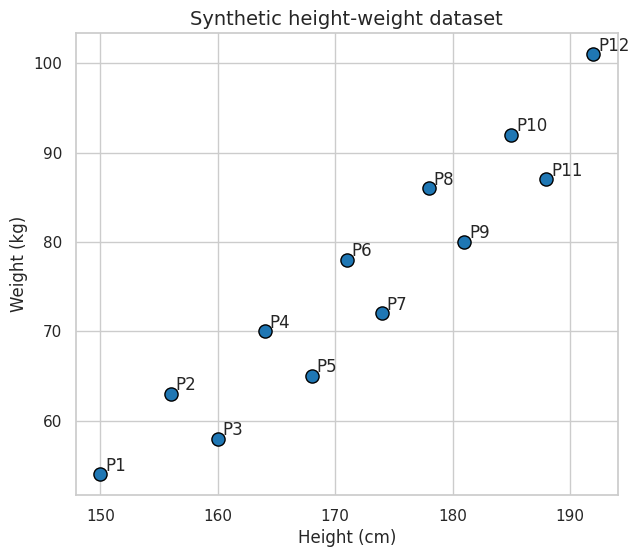

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X[:, 0], X[:, 1], s=90, color="#1f77b4", edgecolor="black")
for person, (height, weight) in zip(people, X):
    ax.text(height + 0.4, weight + 0.4, person.replace("Person_", "P"))
ax.set_title("Synthetic height-weight dataset")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Weight (kg)")
plt.show()

In [7]:
mean_vector = X.mean(axis=0)
X_centered = X - mean_vector

pd.DataFrame(X_centered, columns=["height_centered", "weight_centered"], index=people)

,height_centered,weight_centered
Person_1,-22.25,-21.5
Person_2,-16.25,-12.5
Person_3,-12.25,-17.5
Person_4,-8.25,-5.5
Person_5,-4.25,-10.5
Person_6,-1.25,2.5
Person_7,1.75,-3.5
Person_8,5.75,10.5
Person_9,8.75,4.5
Person_10,12.75,16.5


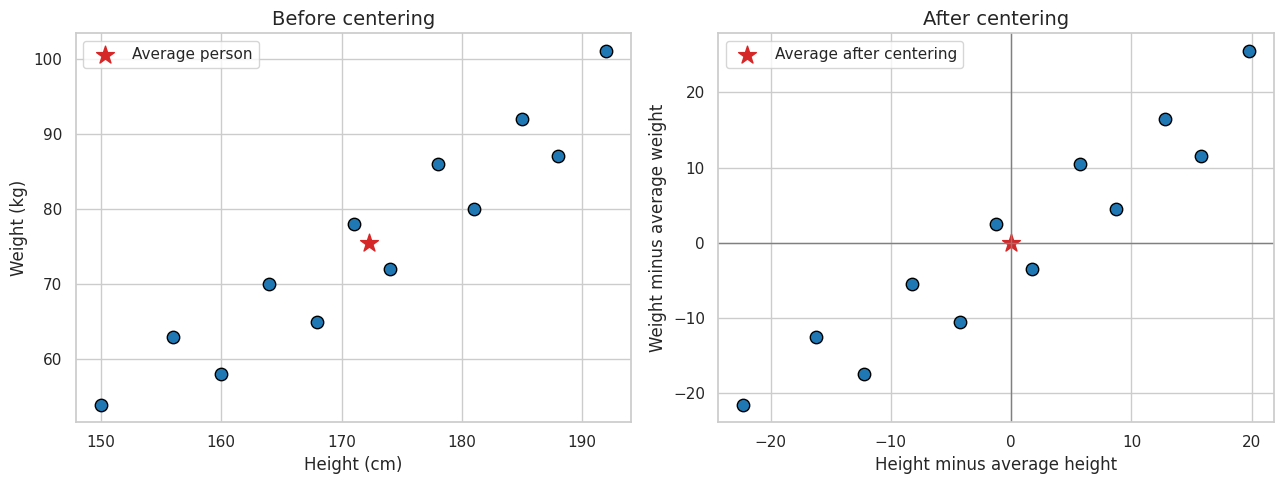

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X[:, 0], X[:, 1], s=80, color="#1f77b4", edgecolor="black")
axes[0].scatter(mean_vector[0], mean_vector[1], s=180, color="#d62728", marker="*", label="Average person")
axes[0].set_title("Before centering")
axes[0].set_xlabel("Height (cm)")
axes[0].set_ylabel("Weight (kg)")
axes[0].legend()

axes[1].axhline(0, color="gray", linewidth=1)
axes[1].axvline(0, color="gray", linewidth=1)
axes[1].scatter(X_centered[:, 0], X_centered[:, 1], s=80, color="#1f77b4", edgecolor="black")
axes[1].scatter(0, 0, s=180, color="#d62728", marker="*", label="Average after centering")
axes[1].set_title("After centering")
axes[1].set_xlabel("Height minus average height")
axes[1].set_ylabel("Weight minus average weight")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
def unit_vector(angle_degrees):
    theta = np.deg2rad(angle_degrees)
    return np.array([np.cos(theta), np.sin(theta)])

candidate_directions = {
    "mostly height direction, 0 deg": unit_vector(0),
    "mostly weight direction, 90 deg": unit_vector(90),
    "equal height-weight direction, 45 deg": unit_vector(45),
    "body-size direction, 55 deg": unit_vector(55),
}

rows = []
for name, w in candidate_directions.items():
    scores = X_centered @ w
    rows.append({
        "direction": name,
        "w_height_weight": w,
        "scores_shape": scores.shape,
        "projected_variance": np.var(scores, ddof=1)
    })
pd.DataFrame(rows)

,direction,w_height_weight,scores_shape,projected_variance
0,"mostly height direction, 0 deg","[1.0, 0.0]","(12,)",173.659091
1,"mostly weight direction, 90 deg","[6.123233995736766e-17, 1.0]","(12,)",206.272727
2,"equal height-weight direction, 45 deg","[0.7071067811865476, 0.7071067811865475]","(12,)",369.193182
3,"body-size direction, 55 deg","[0.5735764363510462, 0.8191520442889918]","(12,)",363.961715


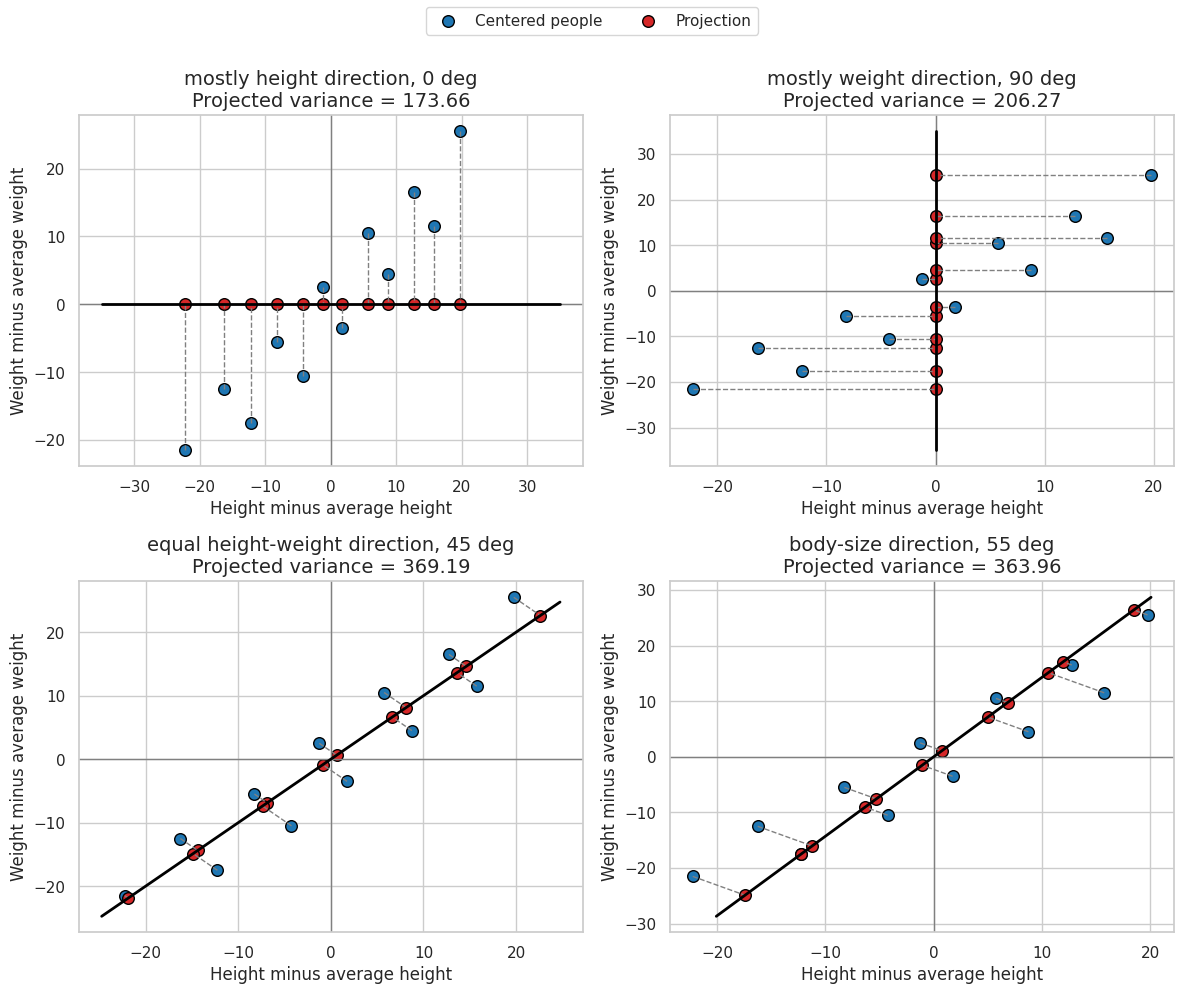

In [13]:
def projection_points(Xc, w):
    scores = Xc @ w
    projected = np.outer(scores, w)
    return scores, projected

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, w) in zip(axes, candidate_directions.items()):
    scores, projected = projection_points(X_centered, w)
    variance = np.var(scores, ddof=1)
    ax.axhline(0, color="gray", linewidth=1)
    ax.axvline(0, color="gray", linewidth=1)
    ax.scatter(X_centered[:, 0], X_centered[:, 1], s=70, color="#1f77b4", edgecolor="black", label="Centered people")
    ax.scatter(projected[:, 0], projected[:, 1], s=70, color="#d62728", edgecolor="black", label="Projection")
    for original, proj in zip(X_centered, projected):
        ax.plot([original[0], proj[0]], [original[1], proj[1]], color="gray", linestyle="--", linewidth=1)
    line = np.array([-35, 35])[:, None] * w
    ax.plot(line[:, 0], line[:, 1], color="black", linewidth=2)
    ax.set_title(f"{name}\nProjected variance = {variance:.2f}")
    ax.set_xlabel("Height minus average height")
    ax.set_ylabel("Weight minus average weight")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [15]:
angles = np.linspace(0, 180, 361)
variances = []

for angle in angles:
    w = unit_vector(angle)
    scores = X_centered @ w
    variance = np.var(scores, ddof=1)
    variances.append(variance)

variance_by_angle = pd.DataFrame({"angle": angles, "projected_variance": variances})
best_idx = variance_by_angle["projected_variance"].idxmax()
best_angle = variance_by_angle.loc[best_idx, "angle"]
best_variance = variance_by_angle.loc[best_idx, "projected_variance"]
best_w_bruteforce = unit_vector(best_angle)

print("Best angle:", best_angle)
print("Best projected variance:", best_variance)
print("Best direction vector:", best_w_bruteforce)

Best angle: 47.5
Best projected variance: 369.93240078574894
Best direction vector: [0.6756 0.7373]


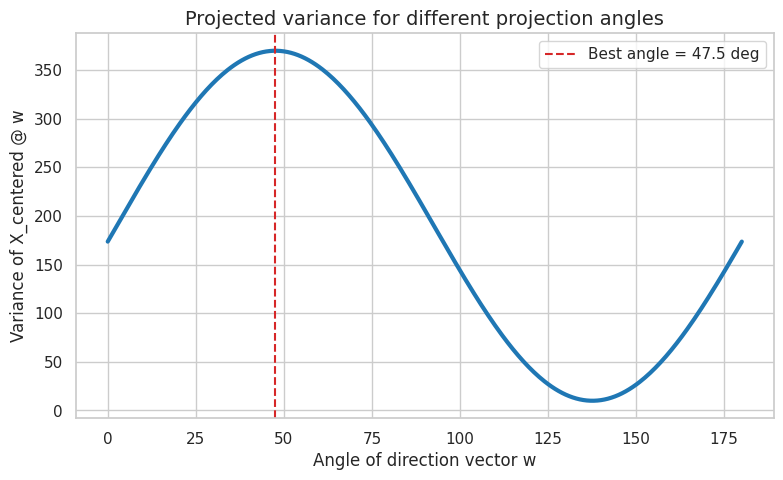

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(variance_by_angle["angle"], variance_by_angle["projected_variance"], color="#1f77b4", linewidth=3)
ax.axvline(best_angle, color="#d62728", linestyle="--", label=f"Best angle = {best_angle:.1f} deg")
ax.set_title("Projected variance for different projection angles")
ax.set_xlabel("Angle of direction vector w")
ax.set_ylabel("Variance of X_centered @ w")
ax.legend()
plt.show()

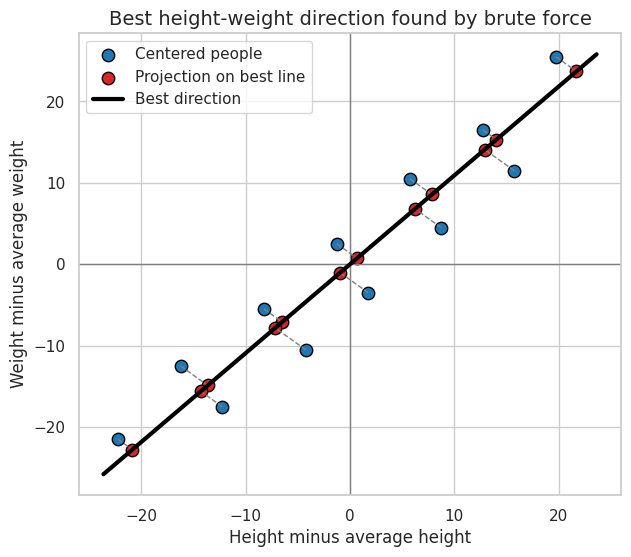

In [17]:
scores_best, projected_best = projection_points(X_centered, best_w_bruteforce)

fig, ax = plt.subplots(figsize=(7, 6))
ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0, color="gray", linewidth=1)
ax.scatter(X_centered[:, 0], X_centered[:, 1], s=80, color="#1f77b4", edgecolor="black", label="Centered people")
ax.scatter(projected_best[:, 0], projected_best[:, 1], s=80, color="#d62728", edgecolor="black", label="Projection on best line")
for original, proj in zip(X_centered, projected_best):
    ax.plot([original[0], proj[0]], [original[1], proj[1]], color="gray", linestyle="--", linewidth=1)
line = np.array([-35, 35])[:, None] * best_w_bruteforce
ax.plot(line[:, 0], line[:, 1], color="black", linewidth=3, label="Best direction")
ax.set_title("Best height-weight direction found by brute force")
ax.set_xlabel("Height minus average height")
ax.set_ylabel("Weight minus average weight")
ax.legend()
plt.show()

In [18]:
scores_best

array([-30.8833, -20.1943, -21.1783,  -9.6286, -10.6127,   0.9987,
        -1.3982,  11.6261,   9.2292,  20.7789,  19.1192,  32.1435])

In [22]:
n = X_centered.shape[0]
cov_manual = X_centered.T @ X_centered / (n - 1)

cov_numpy = np.cov(X_centered.T)
cov_manual, cov_numpy

(array([[173.6591, 179.2273],
        [179.2273, 206.2727]]),
 array([[173.6591, 179.2273],
        [179.2273, 206.2727]]))

In [23]:
eigenvalues, eigenvectors = np.linalg.eig(cov_manual)
eigenvalues, eigenvectors

(array([  9.9983, 369.9335]),
 array([[-0.7384, -0.6743],
        [ 0.6743, -0.7384]]))

In [25]:
order = eigenvalues.argsort()[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]
eigenvalues, eigenvectors

(array([369.9335,   9.9983]),
 array([[-0.6743, -0.7384],
        [-0.7384,  0.6743]]))

In [26]:
pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

In [27]:
pc1, pc2

(array([-0.6743, -0.7384]), array([-0.7384,  0.6743]))

In [29]:
np.linalg.norm(pc2) # pcs are unit vector

np.float64(0.9999999999999999)

In [30]:
np.dot(pc1, pc2) # pcs are othogonal

np.float64(0.0)

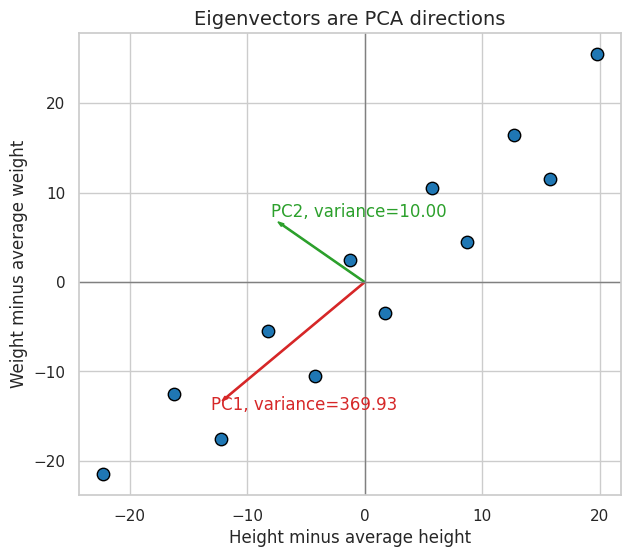

In [31]:
def draw_vector(ax, vector, color, label, scale=12):
    ax.arrow(0, 0, vector[0] * scale, vector[1] * scale,
             color=color, width=0.12, length_includes_head=True)
    ax.text(vector[0] * scale * 1.08, vector[1] * scale * 1.08, label, color=color, fontsize=12)

fig, ax = plt.subplots(figsize=(7, 6))
ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0, color="gray", linewidth=1)
ax.scatter(X_centered[:, 0], X_centered[:, 1], s=80, color="#1f77b4", edgecolor="black")
draw_vector(ax, pc1, "#d62728", f"PC1, variance={eigenvalues[0]:.2f}", scale=18)
draw_vector(ax, pc2, "#2ca02c", f"PC2, variance={eigenvalues[1]:.2f}", scale=10)
ax.set_title("Eigenvectors are PCA directions")
ax.set_xlabel("Height minus average height")
ax.set_ylabel("Weight minus average weight")
plt.show()

In [39]:
angle_pc1 = np.rad2deg(np.arctan2(pc1[1], pc1[0]))
if angle_pc1 < 0:
    angle_pc1 += 180

angle_pc1

np.float64(47.59934347092107)

In [34]:
best_w_bruteforce

array([0.6756, 0.7373])

In [40]:
pc1

array([-0.6743, -0.7384])

In [41]:
W1 = pc1.reshape(-1, 1)
Z1 = X_centered @ W1
Z1

array([[ 30.88  ],
       [ 20.1881],
       [ 21.1831],
       [  9.6245],
       [ 10.6195],
       [ -1.0032],
       [  1.4045],
       [-11.631 ],
       [ -9.2232],
       [-20.7818],
       [-19.1125],
       [-32.1481]])

In [44]:
eigenvalues[0] / np.sum(eigenvalues), eigenvalues[1] / np.sum(eigenvalues)

(np.float64(0.9736838694656254), np.float64(0.026316130534374763))

In [45]:
X_reconstructed_centered = Z1 @ W1.T
X_reconstructed = X_reconstructed_centered + mean_vector
reconstruction_df = pd.DataFrame({
    "original_x": X[:, 0],
    "original_y": X[:, 1],
    "reconstructed_x": X_reconstructed[:, 0],
    "reconstructed_y": X_reconstructed[:, 1],
})
reconstruction_df

,original_x,original_y,reconstructed_x,reconstructed_y
0,150.0,54.0,151.427254,52.696708
1,156.0,63.0,158.636914,60.592111
2,160.0,58.0,157.965978,59.857360
3,164.0,70.0,165.760077,68.392791
4,168.0,65.0,165.089142,67.658040
5,171.0,78.0,172.926489,76.240833
6,174.0,72.0,171.302915,74.462834
7,178.0,86.0,180.092901,84.088875
8,181.0,80.0,178.469327,82.310875
9,185.0,92.0,186.263426,90.846307


In [47]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
explained_variance_ratio

array([0.9737, 0.0263])

In [50]:
pca_1 = PCA(n_components=1)
Z1_sklearn = pca_1.fit_transform(X_centered)

print("sklearn component:")
print(pca_1.components_)
print("\nManual PC1:")
print(pc1)
print("\nsklearn explained variance:")
print(pca_1.explained_variance_)
print("\nManual largest eigenvalue:")
print(eigenvalues[0])
print("\nsklearn explained variance ratio:")
print(pca_1.explained_variance_ratio_)
print("\nManual explained variance ratio:")
print(explained_variance_ratio[0])

sklearn component:
[[0.6743 0.7384]]

Manual PC1:
[-0.6743 -0.7384]

sklearn explained variance:
[369.9335]

Manual largest eigenvalue:
369.9334828603831

sklearn explained variance ratio:
[0.9737]

Manual explained variance ratio:
0.9736838694656254


In [52]:
Z1_sklearn.shape

(12, 1)

In [53]:
wine = load_wine(as_frame=True)
X_wine = wine.data
y_wine = wine.target

print("Shape:", X_wine.shape)
print("Target names:", wine.target_names)
X_wine.head()

Shape: (178, 13)
Target names: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [54]:
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

pca_2 = PCA(n_components=2)
Z_wine_2 = pca_2.fit_transform(X_wine_scaled)

pca_wine_df = pd.DataFrame(Z_wine_2, columns=["PC1", "PC2"])
pca_wine_df["class"] = y_wine
pca_wine_df["class_name"] = pca_wine_df["class"].map(dict(enumerate(wine.target_names)))

print("Explained variance ratio:", pca_2.explained_variance_ratio_)
print("Total variance kept by first 2 PCs:", pca_2.explained_variance_ratio_.sum())
pca_wine_df.head()

Explained variance ratio: [0.362  0.1921]
Total variance kept by first 2 PCs: 0.5540633835693527


,PC1,PC2,class,class_name
0,3.316751,1.443463,0,class_0
1,2.209465,-0.333393,0,class_0
2,2.516740,1.031151,0,class_0
3,3.757066,2.756372,0,class_0
4,1.008908,0.869831,0,class_0


In [56]:
Z_wine_2.shape

(178, 2)

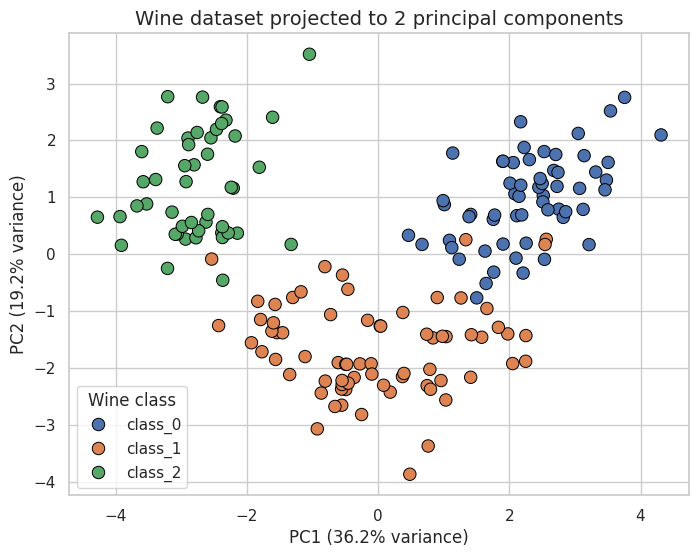

In [57]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=pca_wine_df, x="PC1", y="PC2", hue="class_name", s=80, edgecolor="black", ax=ax)
ax.set_title("Wine dataset projected to 2 principal components")

ax.set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Wine class")
plt.show()

In [62]:
pca_full = PCA()
Z_wine_full = pca_full.fit_transform(X_wine_scaled)

ratios = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ratios)
components = np.arange(1, len(ratios) + 1)

In [63]:
variance_df = pd.DataFrame({
    "component": components,
    "explained_variance_ratio": ratios,
    "cumulative_explained_variance": cumulative
})
variance_df

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623
5,6,0.049358,0.850981
6,7,0.042387,0.893368
7,8,0.026807,0.920175
8,9,0.022222,0.942397
9,10,0.019300,0.961697


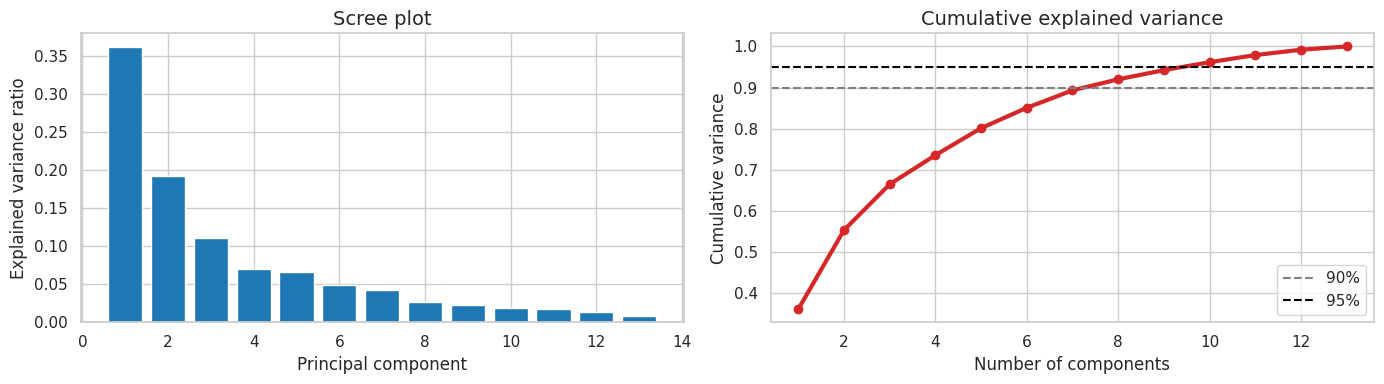

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(components, ratios, color="#1f77b4")
axes[0].set_title("Scree plot")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")

axes[1].plot(components, cumulative, marker="o", color="#d62728", linewidth=3)
axes[1].axhline(0.90, color="gray", linestyle="--", label="90%")
axes[1].axhline(0.95, color="black", linestyle="--", label="95%")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance")
axes[1].legend()

plt.tight_layout()
plt.show()

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=RANDOM_STATE, stratify=y_wine
)

models = {
    "KNN with all scaled features": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ]),
    "KNN with PCA 2 components": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=2)),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ]),
    "KNN with PCA 95% variance": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "KNN with PCA 100% variance": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA()),
        ("knn", KNeighborsClassifier(n_neighbors=5))

    ]),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({"model": name, "test_accuracy": accuracy_score(y_test, pred)})

pd.DataFrame(rows)

,model,test_accuracy
0,KNN with all scaled features,0.933333
1,KNN with PCA 2 components,0.933333
2,KNN with PCA 95% variance,0.955556
3,KNN with PCA 100% variance,0.933333
